# 02. EDA поисковых запросов

Анализируем длину запросов, топ-частоты, слова/n-граммы и позиции кликов.

**Полный датасет:** ~30.99M кликов, ~1.79M уникальных запросов.  
**Семпл:** 400k строк.


In [1]:
%matplotlib inline
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_utils import (
    apply_plot_style, save_fig, ensure_dirs, load_query_clicks, load_sku_desc,
    text_len, parquet_num_rows, parquet_schema_names, dataset_overview_stats,
    save_stats, QUERY_CLICKS_PATH, SKU_DESC_PATH, SKUS_PKL_PATH,
    MVIDEO_RED, DARK_SLATE, MUTED,
)
ensure_dirs()
apply_plot_style()
pd.set_option("display.max_colwidth", 80)
print("ROOT:", ROOT)
from collections import Counter
df = load_query_clicks(n=400_000, seed=42)
print(df.shape)
print("Уникальных запросов в семпле:", df["query_text"].nunique())


ROOT: D:\Projects-26-06-2026\mvideo-ner-search
(400000, 8)
Уникальных запросов в семпле: 99875


## Длина запроса


count    400000.000000
mean         18.339607
std          10.566793
min           1.000000
25%          11.000000
50%          17.000000
75%          23.000000
max         396.000000
Name: query_text, dtype: float64
Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\01_query_length_dist.png


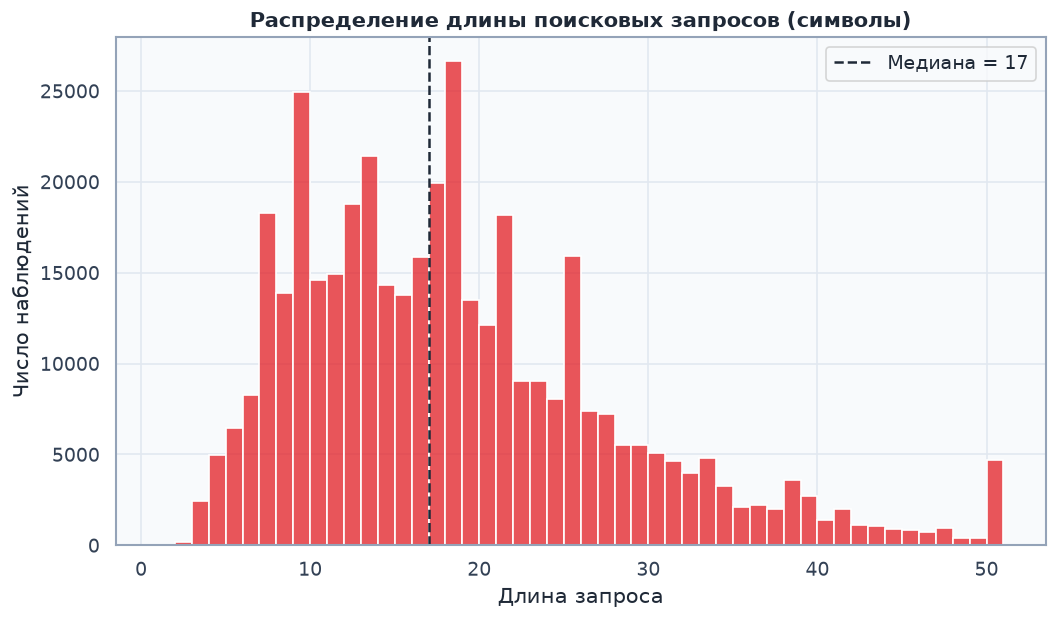

In [2]:
lengths = text_len(df["query_text"])
print(lengths.describe())
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(lengths.clip(upper=lengths.quantile(0.99)), bins=50, color=MVIDEO_RED, edgecolor="white", ax=ax)
ax.axvline(lengths.median(), color=DARK_SLATE, ls="--", lw=1.5, label=f"Медиана = {lengths.median():.0f}")
ax.set_title("Распределение длины поисковых запросов (символы)")
ax.set_xlabel("Длина запроса"); ax.set_ylabel("Число наблюдений"); ax.legend()
save_fig(fig, "01_query_length_dist.png"); plt.show()


## Топ запросов


,clicks
query_text,
стиральная машинка,6111
холодильники,5623
аэрогриль,3763
кондиционер сплит система,2551
микроволновая печь,2544
электрические чайники,2410
телевизор,2234
ноутбук,2097
холодильники двухкамерные,2090


Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\02_top_queries.png


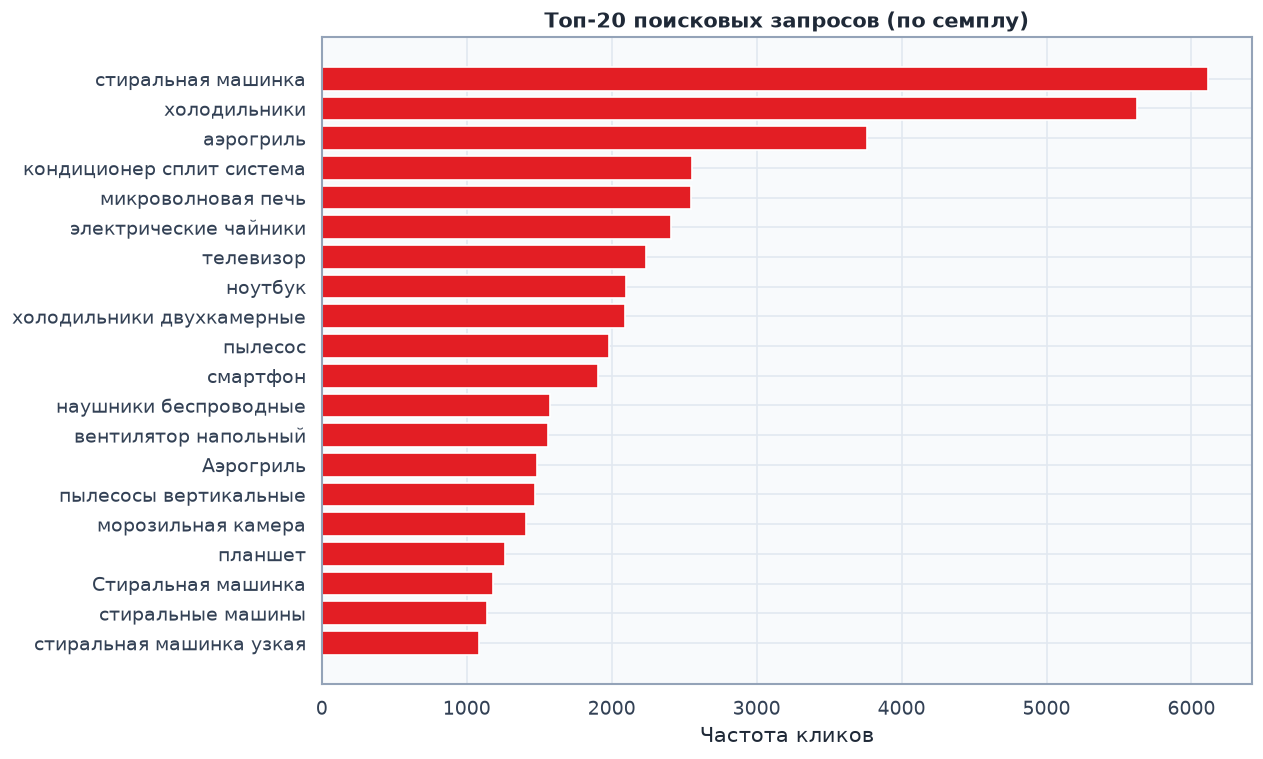

In [3]:
top_q = df["query_text"].value_counts().head(20)
display(top_q.to_frame("clicks"))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_q.index.astype(str)[::-1], top_q.values[::-1], color=MVIDEO_RED)
ax.set_title("Топ-20 поисковых запросов (по семплу)"); ax.set_xlabel("Частота кликов")
save_fig(fig, "02_top_queries.png"); plt.show()


## Частота слов и облако


Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\11_query_word_frequency.png


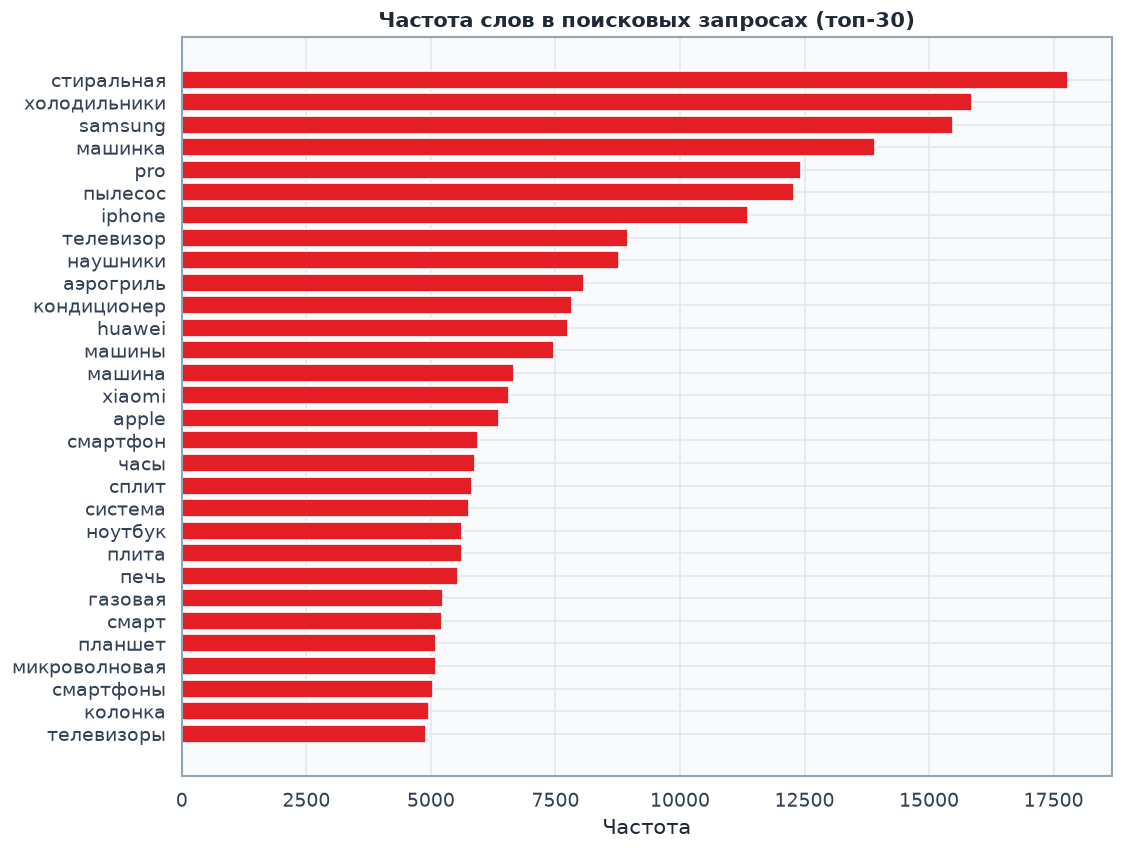

WordCloud недоступен: No module named 'wordcloud'


In [4]:
stop = {"и", "в", "на", "с", "для", "по", "из", "к", "от", "или", "не", "до", "за", "без", "под"}
counts = Counter()
for q in df["query_text"].dropna().astype(str):
    for tok in q.lower().replace("-", " ").split():
        tok = tok.strip(".!?«»\"'()[]")
        if len(tok) >= 3 and tok not in stop and not tok.isdigit():
            counts[tok] += 1
top_words = counts.most_common(30)
words, freqs = zip(*top_words[::-1])
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(words, freqs, color=MVIDEO_RED)
ax.set_title("Частота слов в поисковых запросах (топ-30)"); ax.set_xlabel("Частота")
save_fig(fig, "11_query_word_frequency.png"); plt.show()
try:
    from wordcloud import WordCloud
    wc = WordCloud(width=1400, height=800, background_color="white", colormap="Reds", max_words=120).generate_from_frequencies(dict(counts.most_common(200)))
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title("Облако слов поисковых запросов")
    save_fig(fig, "13_query_wordcloud.png"); plt.show()
except Exception as e:
    print("WordCloud недоступен:", e)


## Распределение позиций клика


count    368384.000000
mean          8.171780
std          11.060577
min           0.000000
25%           0.000000
50%           3.000000
75%          11.000000
max          50.000000
Name: sku_position, dtype: float64
Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\05_position_distribution.png


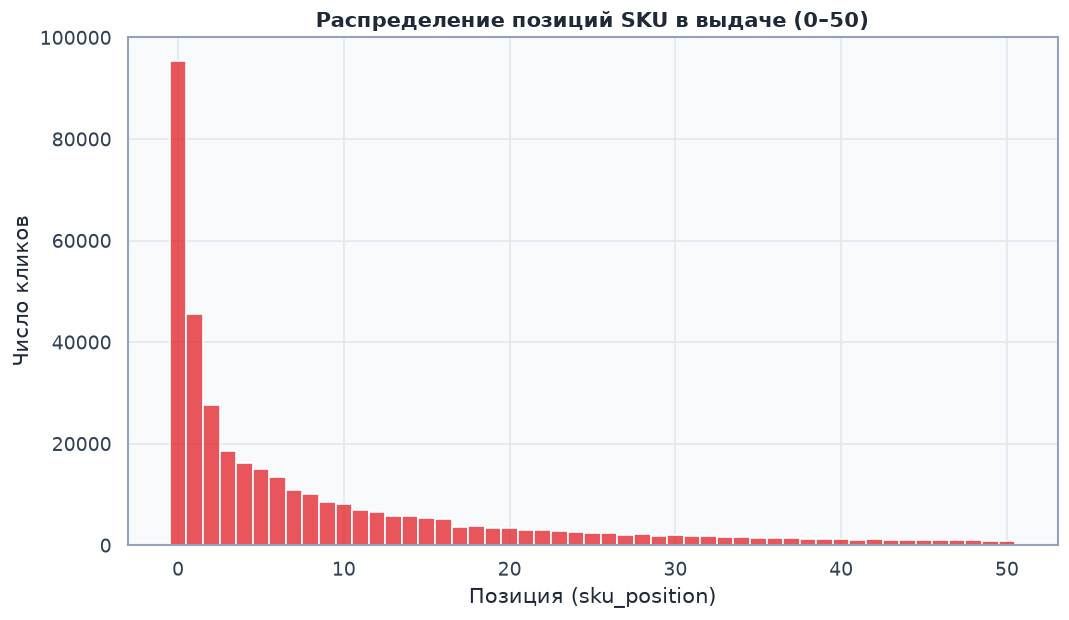

In [5]:
pos = df["sku_position"].dropna()
pos = pos[pos <= 50]
print(pos.describe())
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(pos, bins=51, discrete=True, color=MVIDEO_RED, edgecolor="white", ax=ax)
ax.set_title("Распределение позиций SKU в выдаче (0–50)")
ax.set_xlabel("Позиция (sku_position)"); ax.set_ylabel("Число кликов")
save_fig(fig, "05_position_distribution.png"); plt.show()


## Биграммы (топ)


Сохранено: D:\Projects-26-06-2026\mvideo-ner-search\figures\17_query_bigrams.png


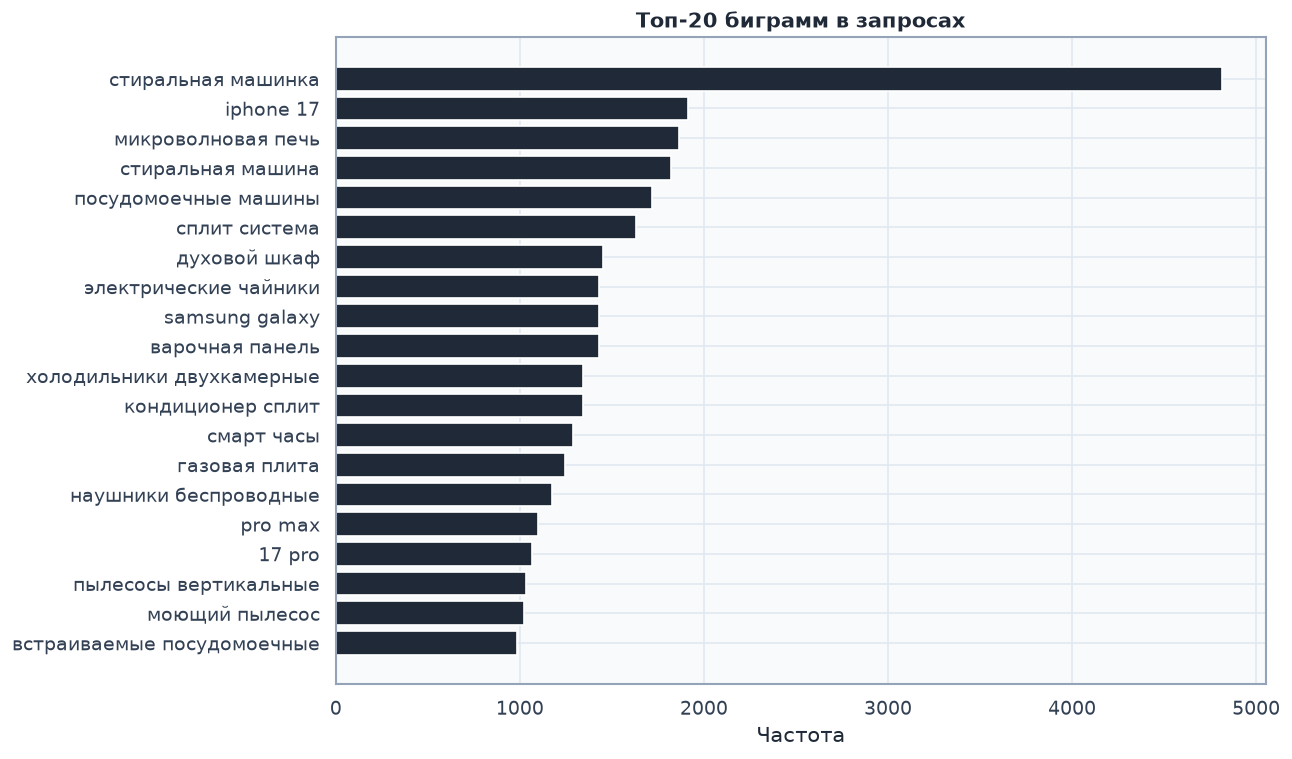

In [6]:
bigrams = Counter()
for q in df["query_text"].dropna().astype(str).head(150_000):
    toks = [t.strip(".!?«»\"'()[]") for t in q.lower().split() if len(t.strip(".!?")) >= 2]
    for a, b in zip(toks, toks[1:]):
        bigrams[f"{a} {b}"] += 1
bg = bigrams.most_common(20)
labels, vals = zip(*bg[::-1])
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(labels, vals, color=DARK_SLATE)
ax.set_title("Топ-20 биграмм в запросах"); ax.set_xlabel("Частота")
save_fig(fig, "17_query_bigrams.png"); plt.show()
